In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#importing packages and classes from tensorflow and keras
import seaborn as sns
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
from tkinter.filedialog import askopenfilename
import numpy as np
import pandas as pd
import os
import cv2
from keras.utils.np_utils import to_categorical
from tensorflow.keras.layers import  MaxPooling2D
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, GlobalAveragePooling2D
from tensorflow.keras.layers import Convolution2D
from tensorflow.keras.models import Sequential, load_model, Model
import pickle
#from classification_models.resnet import ResNet18 #loading propose resnet18 as backbone model
from tensorflow.keras.applications import VGG16, ResNet50 #loading existing VGG16 model
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from keras.callbacks import ModelCheckpoint
import keras
from Attention import attention #importing attention layer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, InputLayer, BatchNormalization
from sklearn.metrics import confusion_matrix

In [3]:
#load and display dataset labels
path = "Dataset"
labels = []
for root, dirs, directory in os.walk(path):
    for j in range(len(directory)):
        name = os.path.basename(root)
        if name not in labels:
            labels.append(name.strip())
print("Labels found in dataset : "+str(labels))
#function to get label class id
def getLabel(name):
    index = -1
    for i in range(len(labels)):
        if labels[i] == name:
            index = i
            break
    return index

Labels found in dataset : ['DarkRed', 'LightRed', 'Purple', 'Red']


In [4]:
#load and process dataset image features
if os.path.exists('model/X.txt.npy'):#if images already process then load it
    X = np.load('model/X.txt.npy')
    Y = np.load('model/Y.txt.npy')
else:
    X = []
    Y = []
    #read and process dataset images
    for root, dirs, directory in os.walk(path):#loop all images in dataset
        for j in range(len(directory)):
            name = os.path.basename(root)
            if 'Thumbs.db' not in directory[j]:
                img = cv2.imread(root+"/"+directory[j])#read each image
                img = cv2.resize(img, (32,32))#resize image
                X.append(img)#add image features to X array
                label = getLabel(name)#get label from give image class
                Y.append(label)#add label to Y
    X = np.asarray(X)
    Y = np.asarray(Y)
    np.save('model/X.txt',X)
    np.save('model/Y.txt',Y)            
print("Dataset Tongue Images Loading Completed")
print("Total images found in dataset : "+str(X.shape[0]))

Dataset Tongue Images Loading Completed
Total images found in dataset : 482


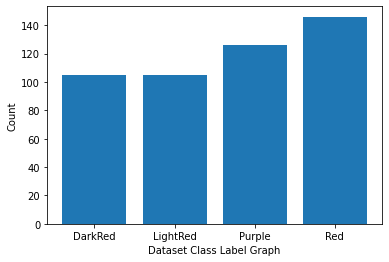

In [5]:
#find and plot images in each class label
unqiue, count = np.unique(Y, return_counts = True)
height = count
bars = labels
y_pos = np.arange(len(bars))
plt.bar(y_pos, height)
plt.xticks(y_pos, bars)
plt.xlabel("Dataset Class Label Graph")
plt.ylabel("Count")
plt.show()

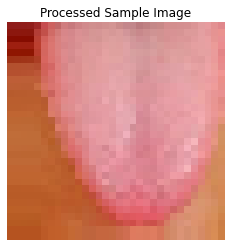

In [6]:
#display sample process image
img = X[0]
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.title('Processed Sample Image')
plt.axis('off')
plt.show()

In [7]:
#dataset preprocessing such as shuffling and normalization
X = X.astype('float32')
X = X/255 #normalizing images
indices = np.arange(X.shape[0])
np.random.shuffle(indices)#shuffling images
X = X[indices]
Y = Y[indices]
Y = to_categorical(Y)
print("Dataset Normalization & Shuffling Process completed")

Dataset Normalization & Shuffling Process completed


In [8]:
#now splitting dataset into train & test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2) #split dataset into train and test
print()
print("Dataset train & test split as 80% dataset for training and 20% for testing")
print("Training Size (80%): "+str(X_train.shape[0])) #print training and test size
print("Testing Size (20%): "+str(X_test.shape[0]))
print()


Dataset train & test split as 80% dataset for training and 20% for testing
Training Size (80%): 385
Testing Size (20%): 97



In [9]:
#define global variables to calculate and store accuracy and other metrics
precision = []
recall = []
fscore = []
accuracy = []

In [28]:
ML_Model = []
acc = []
prec = []
rec = []
f1 = []

#function to call for storing the results
def storeResults(model, a,b,c,d):
    ML_Model.append(model)
    acc.append(round(a, 3))
    prec.append(round(b, 3))
    rec.append(round(c, 3))
    f1.append(round(d, 3))

In [11]:
#function to calculate various metrics such as accuracy, precision etc
def calculateMetrics(algorithm, predict, testY):
    p = precision_score(testY, predict,average='macro') * 100
    r = recall_score(testY, predict,average='macro') * 100
    f = f1_score(testY, predict,average='macro') * 100
    a = accuracy_score(testY,predict)*100     
    print()
    print("Class Wise Classification Report")
    print(classification_report(testY, predict, target_names=labels))
    print(algorithm+' Overall Accuracy : '+str(a))
    print(algorithm+' Overall MAP      : '+str(p))
    print(algorithm+' Overall Recall   : '+str(r))
    print(algorithm+' Overall FSCORE   : '+str(f))    
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    conf_matrix = confusion_matrix(testY, predict) 
    plt.figure(figsize =(5, 4)) 
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="viridis" ,fmt ="g");
    ax.set_ylim([0,len(labels)])
    plt.title(algorithm+" Confusion matrix") 
    plt.ylabel('True class') 
    plt.xlabel('Predicted class') 
    plt.show()

# VGG16


Class Wise Classification Report
              precision    recall  f1-score   support

     DarkRed       0.95      0.90      0.93        21
    LightRed       0.90      1.00      0.95        18
      Purple       1.00      1.00      1.00        31
         Red       0.96      0.93      0.94        27

    accuracy                           0.96        97
   macro avg       0.95      0.96      0.95        97
weighted avg       0.96      0.96      0.96        97

Existing VGG16 Overall Accuracy : 95.87628865979381
Existing VGG16 Overall MAP      : 95.28846153846155
Existing VGG16 Overall Recall   : 95.76719576719577
Existing VGG16 Overall FSCORE   : 95.43984789401023


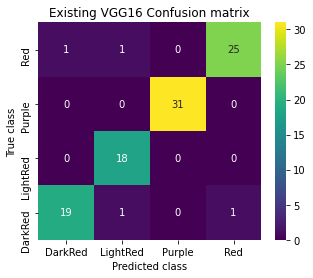

In [12]:
#train existing VGG algorithm
#create VGG object
vgg = VGG16(input_shape=(X_train.shape[1], X_train.shape[2], X_train.shape[3]), include_top=False, weights='imagenet')
for layer in vgg.layers:
    layer.trainable = False
vgg_model = Sequential()
#define VGG as the base model
vgg_model.add(vgg)
#add new CNN layer for features filtration
vgg_model.add(Convolution2D(32, (1 , 1), input_shape = (X_train.shape[1], X_train.shape[2], X_train.shape[3]), activation = 'relu'))
#max layer to collect relevant features from previous CNN layer
vgg_model.add(MaxPooling2D(pool_size = (1, 1)))
vgg_model.add(Convolution2D(32, (1, 1), activation = 'relu'))
vgg_model.add(MaxPooling2D(pool_size = (1, 1)))
vgg_model.add(attention(return_sequences=True,name='attention')) # define Attention layer
vgg_model.add(Flatten())
#defining output layer
vgg_model.add(Dense(units = 256, activation = 'relu'))
vgg_model.add(Dense(units = y_train.shape[1], activation = 'softmax'))
#compile and train the model
vgg_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/vgg_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/vgg_weights.hdf5', verbose = 1, save_best_only = True)
    hist = vgg_model.fit(X_train, y_train, batch_size = 32, epochs = 200, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/vgg_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    vgg_model = load_model("model/vgg_weights.hdf5", custom_objects={'attention': attention})
#perform prediction on test data   
predict = vgg_model.predict(X_test)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test, axis=1)
#calculate function to calculate algorithm prediction accuracy
calculateMetrics("Existing VGG16", predict, y_test1)

In [13]:
vgg_acc = accuracy_score(predict, y_test1)
vgg_prec = precision_score(predict, y_test1,average='macro')
vgg_rec = recall_score(predict, y_test1,average='macro')
vgg_f1 = f1_score(predict, y_test1,average='macro')

In [29]:
storeResults('Existing VGG16',vgg_acc,vgg_prec,vgg_rec,vgg_f1)

# ResNet18

In [16]:
#train propose E-CA2-ResNet18 algorithm where E refers to activating activation function, CA refers to Attention model for 
#features optimization and ResNet18 will be used as based model to get trained on noisy and clear label and this model is
#called as Teacher model and the extracted features will be input to Student model to calculate threshod between noisy
#predicted labels and the labels with clean label will have high qualitu features from Attention so it will have high 
#probability score and will be predicted as output
#Define resnet18 as based backbone model
resnet_model = ResNet50(input_shape=(X_train.shape[1], X_train.shape[2], X_train.shape[3]), weights='imagenet', include_top=False)
#for layer in resnet_model.layers:
    #layer.trainable = False
#add teacher and student layers to backbone resnet18 model
resnet_model = Sequential() #create CNN model
#define layer which will act as Teacher model on noisy and clean features from X input data
resnet_model.add(InputLayer(input_shape=(X_train.shape[1], X_train.shape[2], X_train.shape[3])))
#teacher model will use Conv2D layer to filter out all noisy and clean features
resnet_model.add(Conv2D(25, (5, 5), activation='relu', strides=(1, 1), padding='same'))
#teacher module will use max layer to collect all noisy and clean features and then assigned high threshold 
resnet_model.add(MaxPool2D(pool_size=(2, 2), padding='same'))
#another Conv2d layer for further filtration
resnet_model.add(Conv2D(50, (5, 5), activation='relu', strides=(2, 2), padding='same'))
resnet_model.add(MaxPool2D(pool_size=(2, 2), padding='same'))
resnet_model.add(BatchNormalization())
#studnet CNN module to get optimized features from teacher module and then use prediction or output layer 
#to calculate prediction thrshold and then select predicted label with high probability
resnet_model.add(Conv2D(70, (1, 1), activation='relu', strides=(1, 1), padding='same'))
resnet_model.add(MaxPool2D(pool_size=(1, 1), padding='valid'))
resnet_model.add(BatchNormalization())
resnet_model.add(attention(return_sequences=True,name='attention')) # define Attention layer
resnet_model.add(Flatten())
#output layer
resnet_model.add(Dense(units=100, activation='relu'))
resnet_model.add(Dense(units=100, activation='relu'))
resnet_model.add(Dropout(0.25))
resnet_model.add(Dense(units=y_train.shape[1], activation='softmax'))
#train and compile the model
resnet_model.compile(loss='categorical_crossentropy', optimizer="adam", metrics=['accuracy'])
#if os.path.exists("model/resnet_weights.hdf5") == False:
    #model_check_point = ModelCheckpoint(filepath='model/resnet_weights.hdf5', verbose = 1, save_best_only = True)
hist = resnet_model.fit(X_train, y_train, batch_size = 2, epochs = 200, validation_data=(X_test, y_test), verbose=1)
    #f = open('model/resnet_history.pckl', 'wb')
    ##pickle.dump(hist.history, f)
    #f.close()    
#else:
    #resnet_model.load_weights("model/resnet_weights.hdf5")
#perfrom prediction on test data   

Epoch 1/200
193/193 [==============================] - 2s 8ms/step - loss: 1.2830 - accuracy: 0.4234 - val_loss: 1.4080 - val_accuracy: 0.3818
Epoch 2/200
193/193 [==============================] - 1s 7ms/step - loss: 1.0833 - accuracy: 0.5143 - val_loss: 1.2416 - val_accuracy: 0.4805
Epoch 3/200
193/193 [==============================] - 1s 7ms/step - loss: 0.9243 - accuracy: 0.5974 - val_loss: 0.9145 - val_accuracy: 0.6052
Epoch 4/200
193/193 [==============================] - 1s 7ms/step - loss: 0.7959 - accuracy: 0.6649 - val_loss: 2.7727 - val_accuracy: 0.3273
Epoch 5/200
193/193 [==============================] - 1s 7ms/step - loss: 0.6441 - accuracy: 0.7299 - val_loss: 0.6345 - val_accuracy: 0.7299
Epoch 6/200
193/193 [==============================] - 1s 7ms/step - loss: 0.5353 - accuracy: 0.8000 - val_loss: 0.4647 - val_accuracy: 0.8597
Epoch 7/200
193/193 [==============================] - 1s 7ms/step - loss: 0.4962 - accuracy: 0.8234 - val_loss: 1.0904 - val_accuracy: 0.5922

Epoch 58/200
193/193 [==============================] - 1s 7ms/step - loss: 0.0988 - accuracy: 0.9688 - val_loss: 0.1361 - val_accuracy: 0.9610
Epoch 59/200
193/193 [==============================] - 1s 7ms/step - loss: 0.0722 - accuracy: 0.9818 - val_loss: 0.0973 - val_accuracy: 0.9636
Epoch 60/200
193/193 [==============================] - 1s 7ms/step - loss: 0.1248 - accuracy: 0.9662 - val_loss: 0.1163 - val_accuracy: 0.9766
Epoch 61/200
193/193 [==============================] - 1s 7ms/step - loss: 0.0710 - accuracy: 0.9766 - val_loss: 0.5337 - val_accuracy: 0.9221
Epoch 62/200
193/193 [==============================] - 1s 7ms/step - loss: 0.0660 - accuracy: 0.9714 - val_loss: 0.0300 - val_accuracy: 0.9870
Epoch 63/200
193/193 [==============================] - 1s 7ms/step - loss: 0.0302 - accuracy: 0.9870 - val_loss: 0.0318 - val_accuracy: 0.9896
Epoch 64/200
193/193 [==============================] - 1s 7ms/step - loss: 0.0157 - accuracy: 0.9922 - val_loss: 0.1019 - val_accuracy:

193/193 [==============================] - 1s 7ms/step - loss: 0.0018 - accuracy: 1.0000 - val_loss: 0.0020 - val_accuracy: 1.0000
Epoch 115/200
193/193 [==============================] - 1s 7ms/step - loss: 0.0010 - accuracy: 1.0000 - val_loss: 0.0017 - val_accuracy: 1.0000
Epoch 116/200
193/193 [==============================] - 1s 7ms/step - loss: 0.0015 - accuracy: 1.0000 - val_loss: 0.0011 - val_accuracy: 1.0000
Epoch 117/200
193/193 [==============================] - 1s 7ms/step - loss: 0.0015 - accuracy: 1.0000 - val_loss: 7.5267e-04 - val_accuracy: 1.0000
Epoch 118/200
193/193 [==============================] - 1s 7ms/step - loss: 0.0259 - accuracy: 0.9974 - val_loss: 0.0768 - val_accuracy: 0.9818
Epoch 119/200
193/193 [==============================] - 1s 7ms/step - loss: 0.1360 - accuracy: 0.9714 - val_loss: 0.1658 - val_accuracy: 0.9506
Epoch 120/200
193/193 [==============================] - 1s 7ms/step - loss: 0.0302 - accuracy: 0.9844 - val_loss: 0.0370 - val_accuracy: 0.

Epoch 170/200
193/193 [==============================] - 1s 7ms/step - loss: 0.0526 - accuracy: 0.9844 - val_loss: 0.0193 - val_accuracy: 0.9974
Epoch 171/200
193/193 [==============================] - 1s 7ms/step - loss: 0.0185 - accuracy: 0.9948 - val_loss: 0.0033 - val_accuracy: 1.0000
Epoch 172/200
193/193 [==============================] - 1s 7ms/step - loss: 0.0056 - accuracy: 0.9974 - val_loss: 0.0238 - val_accuracy: 0.9948
Epoch 173/200
193/193 [==============================] - 1s 7ms/step - loss: 0.0026 - accuracy: 1.0000 - val_loss: 0.0016 - val_accuracy: 1.0000
Epoch 174/200
193/193 [==============================] - 1s 7ms/step - loss: 0.0019 - accuracy: 1.0000 - val_loss: 5.9134e-04 - val_accuracy: 1.0000
Epoch 175/200
193/193 [==============================] - 1s 7ms/step - loss: 8.0853e-04 - accuracy: 1.0000 - val_loss: 6.2084e-04 - val_accuracy: 1.0000
Epoch 176/200
193/193 [==============================] - 1s 7ms/step - loss: 0.0011 - accuracy: 1.0000 - val_loss: 0.0


Class Wise Classification Report
              precision    recall  f1-score   support

     DarkRed       1.00      1.00      1.00        84
    LightRed       1.00      1.00      1.00        87
      Purple       1.00      1.00      1.00        95
         Red       1.00      1.00      1.00       119

    accuracy                           1.00       385
   macro avg       1.00      1.00      1.00       385
weighted avg       1.00      1.00      1.00       385

Propose E-CA2-ResNet18 Overall Accuracy : 100.0
Propose E-CA2-ResNet18 Overall MAP      : 100.0
Propose E-CA2-ResNet18 Overall Recall   : 100.0
Propose E-CA2-ResNet18 Overall FSCORE   : 100.0


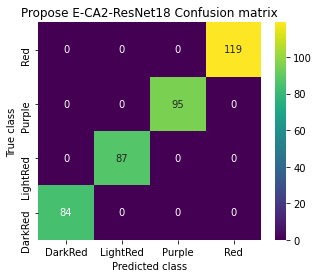

In [17]:
predict = resnet_model.predict(X_test)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test, axis=1)
#calculate function to calculate algorithm prediction accuracy
calculateMetrics("Propose E-CA2-ResNet18", predict, y_test1)

In [18]:
res_acc = accuracy_score(predict, y_test1)
res_prec = precision_score(predict, y_test1,average='macro')
res_rec = recall_score(predict, y_test1,average='macro')
res_f1 = f1_score(predict, y_test1,average='macro')

In [30]:
storeResults('Propose E-CA2-ResNet18',res_acc,res_prec,res_rec,res_f1)

# Hybrid Model


Class Wise Classification Report
              precision    recall  f1-score   support

     DarkRed       1.00      1.00      1.00        89
    LightRed       1.00      1.00      1.00        81
      Purple       1.00      1.00      1.00        99
         Red       1.00      1.00      1.00       116

    accuracy                           1.00       385
   macro avg       1.00      1.00      1.00       385
weighted avg       1.00      1.00      1.00       385

Hybrid Extension Model Overall Accuracy : 100.0
Hybrid Extension Model Overall MAP      : 100.0
Hybrid Extension Model Overall Recall   : 100.0
Hybrid Extension Model Overall FSCORE   : 100.0


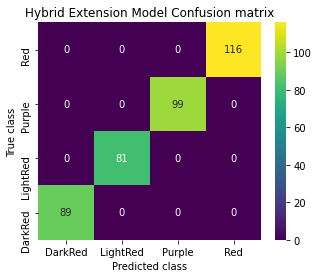

In [25]:
#train extension hybrid Random forest model by collecting clean fetaures from propose E-CA2-ResNet18 model and then
#evaluate performance on test data
#build resnet model
hybrid_model = Model(resnet_model.inputs, resnet_model.layers[-3].output)#create CNN  model
hybrid_features = hybrid_model.predict(X)  #extracting resnet features
Y1 = np.argmax(Y, axis=1)
#split features into train and test
X_train, X_test, y_train, y_test = train_test_split(hybrid_features, Y1, test_size=0.2) #split dataset into train and test
#now create Random Forest object
rf = RandomForestClassifier()
#trained on Resnet18 features
rf.fit(X_train, y_train)
#predict on test data
predict = rf.predict(X_test)
#calculate function to calculate algorithm prediction accuracy
calculateMetrics("Hybrid Extension Model", predict, y_test)

In [27]:
ext_acc = accuracy_score(predict, y_test)
ext_prec = precision_score(predict, y_test,average='macro')
ext_rec = recall_score(predict, y_test,average='macro')
ext_f1 = f1_score(predict, y_test,average='macro')

In [31]:
storeResults('Hybrid Extension Model',ext_acc,ext_prec,ext_rec,ext_f1)

# Comparison

In [32]:
#creating dataframe
import pandas as pd
import numpy as np
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : acc,
                        'f1_score' : f1,
                        'Recall'   : rec,
                        'Precision': prec,
                        
                      })

In [33]:
result

,ML Model,Accuracy,f1_score,Recall,Precision
0,Existing VGG16,0.959,0.954,0.953,0.958
1,Propose E-CA2-ResNet18,1.000,1.000,1.000,1.000
2,Hybrid Extension Model,1.000,1.000,1.000,1.000


In [39]:
import joblib
filename = 'model.sav'
joblib.dump(rf, filename)

['model.sav']

# Graph

In [34]:
classifier = ML_Model
y_pos = np.arange(len(classifier))

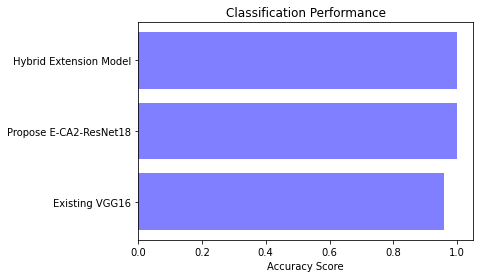

In [35]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, acc, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

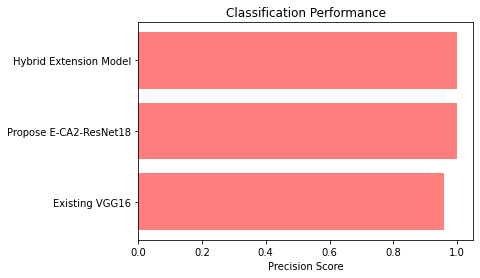

In [36]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, prec, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

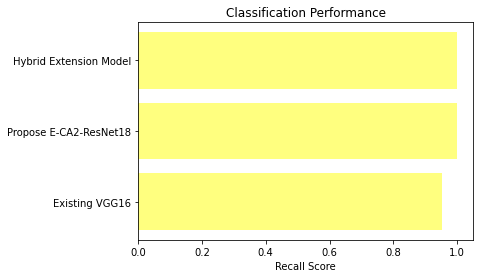

In [37]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, rec, align='center', alpha=0.5,color='yellow')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Recall Score')
plt2.title('Classification Performance')
plt2.show()

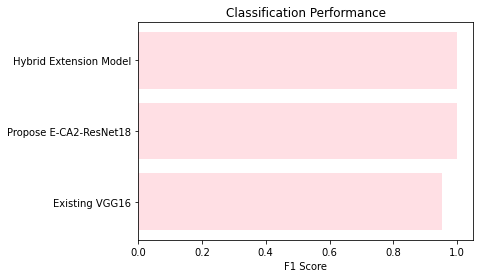

In [38]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, f1, align='center', alpha=0.5,color='pink')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()

# Prediction

In [40]:
#predict tongue colour from test image
def predictTongueColour(test_image):
    image = cv2.imread(test_image)#read image from given path
    img = cv2.resize(image, (32,32))#resize image
    im2arr = np.array(img)
    im2arr = im2arr.reshape(1,32,32,3)#convert image into 4 dimension
    img = np.asarray(im2arr)
    img = img.astype('float32')
    img = img/255 #normalizing test image
    features = hybrid_model.predict(img)#now using propose E-CA2-ResNet18 extarct features from input image
    predict = rf.predict(features)#using extension random forest perform prediction on extrated features
    predict = predict[0]
    img = cv2.imread(test_image)
    img = cv2.resize(img, (600,400))
    #display predicted labels
    cv2.putText(img, 'Prediction Colour : '+labels[predict], (10, 25),  cv2.FONT_HERSHEY_SIMPLEX,0.8, (255, 0, 0), 2)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

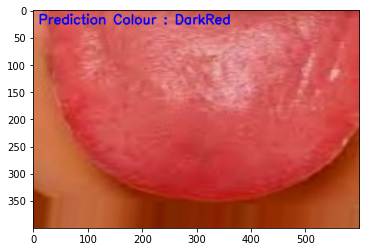

In [41]:
#call predict function with tongue image to predict colour
predictTongueColour("testImages/1.png")

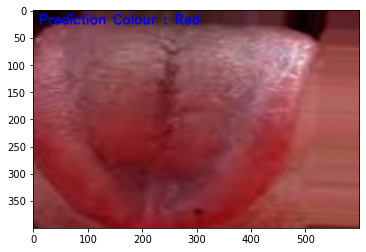

In [42]:
#call predict function with tongue image to predict colour
predictTongueColour("testImages/6.png")

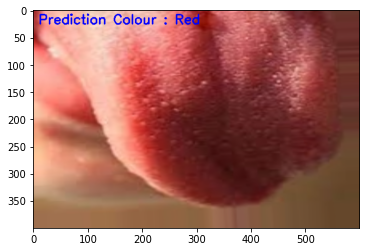

In [43]:
#call predict function with tongue image to predict colour
predictTongueColour("testImages/2.png")

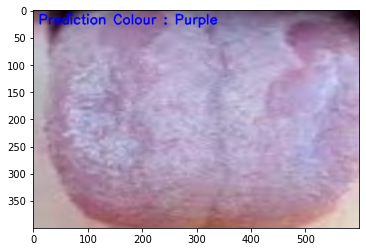

In [44]:
#call predict function with tongue image to predict colour
predictTongueColour("testImages/7.png")